<a href="https://colab.research.google.com/github/cocyten27/MODULE_6/blob/main/M6_L23_musicgen_audiogen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TAE-IA · Módulo 6 · L23 — Generating Music and Sound: MusicGen and AudioLDM2

| | |
|---|---|
| **Models** | MusicGen-small (transformer over EnCodec tokens, 2.4 GB) · AudioLDM2 (latent diffusion, ~4.5 GB) |
| **Also used** | CLAP — AudioLDM2's own text/audio encoder — to score prompt adherence |
| **Runtime** | T4 GPU · ~7 GB on the runtime disk, re-downloaded each session |
| **Outputs** | `TAE_IA_M6/L23_output/` on Drive |
| **Licences** | MusicGen weights CC BY-NC 4.0 · AudioLDM2 weights CC BY-NC-SA 4.0 — **non-commercial** |

## Learning objectives

1. Compute what a text-to-music transformer actually generates: tokens per second, codebooks, bits
2. Measure how guidance and temperature trade prompt adherence against quality and variety
3. Generate sound effects with latent diffusion and measure what the number of steps buys
4. Score prompt adherence with CLAP — and find where the score disagrees with your ears
5. Mix generated music and effects into one scene with correct resampling and gain

## 1 — Setup

`transformers` is already on Colab; `diffusers` needs an update. Weights go to the runtime disk.

In [1]:
!pip install -q -U diffusers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 10.9 MB/s eta 0:00:00


In [2]:
import os, time, random
import numpy as np
import torch

from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = '/content/drive/MyDrive/TAE_IA_M6'
OUTPUT_DIR = f'{DRIVE_ROOT}/L23_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)
MODEL_CACHE = '/content/models'
os.makedirs(MODEL_CACHE, exist_ok=True)
os.environ['HF_HOME'] = MODEL_CACHE

if not torch.cuda.is_available():
    raise SystemExit('No GPU. Runtime > Change runtime type > T4 GPU')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

import soundfile as sf, librosa, librosa.display
import matplotlib.pyplot as plt
import IPython.display as ipd
import pandas as pd
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

def save(wav, sr, name):
    path = f'{OUTPUT_DIR}/{name}.wav'
    sf.write(path, np.asarray(wav, dtype=np.float32), sr)
    return path

def play(wav, sr, label=''):
    print(f'{label}  ({len(wav) / sr:.1f} s)')
    ipd.display(ipd.Audio(wav, rate=sr))

def spec_grid(clips, titles, path, ncols=3, fmax=8000):
    n = len(clips); nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 2.8 * nrows), squeeze=False)
    for ax, (wav, sr), title in zip(axes.flat, clips, titles):
        S_db = librosa.power_to_db(librosa.feature.melspectrogram(y=wav, sr=sr, n_mels=96, fmax=fmax), ref=np.max)
        librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', fmax=fmax, ax=ax)
        ax.set_title(title, fontsize=9)
    for ax in list(axes.flat)[n:]:
        ax.axis('off')
    plt.tight_layout(); plt.savefig(path); plt.show()

def vram(tag=''):
    print(f'  VRAM {torch.cuda.memory_allocated() / 1e9:5.2f} GB   {tag}')

print(torch.cuda.get_device_name(0))

Mounted at /content/drive
Tesla T4


## 2 — MusicGen: what it actually generates

MusicGen never produces samples. It produces **EnCodec tokens**: several codebooks per frame, at a
fixed frame rate. The config tells you the whole budget before you generate anything.

In [3]:
from transformers import AutoProcessor, MusicgenForConditionalGeneration

t0 = time.time()
mg_proc  = AutoProcessor.from_pretrained('facebook/musicgen-small')
musicgen = MusicgenForConditionalGeneration.from_pretrained('facebook/musicgen-small', dtype=torch.float16).to('cuda').eval()
print(f'MusicGen-small loaded in {time.time() - t0:.0f} s'); vram('MusicGen')

MG_SR         = musicgen.config.audio_encoder.sampling_rate
FRAME_RATE    = musicgen.config.audio_encoder.frame_rate
N_CODEBOOKS   = musicgen.config.decoder.num_codebooks
CODEBOOK_SIZE = musicgen.config.audio_encoder.codebook_size

seconds = 10
tokens = seconds * FRAME_RATE * N_CODEBOOKS
bitrate = FRAME_RATE * N_CODEBOOKS * np.log2(CODEBOOK_SIZE)
pcm = MG_SR * 16
print(f'sample rate {MG_SR} Hz | frame rate {FRAME_RATE} Hz | {N_CODEBOOKS} codebooks x {CODEBOOK_SIZE} codes')
print(f'{seconds} s of music = {seconds * FRAME_RATE} frames = {tokens} tokens')
print(f'token bitrate {bitrate:.0f} bit/s vs 16-bit PCM {pcm} bit/s -> {pcm / bitrate:.0f}x smaller')

preprocessor_config.json:   0%|          | 0.00/275 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/7.87k [00:00<?, ?B/s]

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 2047), got 2048. This may result in unexpected behavior.
[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 2047), got 2048. This may result in unexpected behavior.


tokenizer_config.json:   0%|          | 0.00/2.37k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.36GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/611 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

MusicGen-small loaded in 41 s
  VRAM  1.25 GB   MusicGen
sample rate 32000 Hz | frame rate 50 Hz | 4 codebooks x 2048 codes
10 s of music = 500 frames = 2000 tokens
token bitrate 2200 bit/s vs 16-bit PCM 512000 bit/s -> 233x smaller


6 x 10 s generated in one batch: 14.5 s
Uplifting bossa nova with acoustic guitar, soft percussion and piano  (9.9 s)


Tense cinematic strings building to a dramatic climax, minor key  (9.9 s)


Lo-fi hip hop with vinyl crackle, slow piano chords, relaxed drums, 80 BPM  (9.9 s)


Energetic electronic dance music with a driving synth bass and four-on-the-floor kick  (9.9 s)


Peaceful ambient pads with slow evolving textures and no percussion  (9.9 s)


Mariachi band with trumpets, violins and guitarrón, festive  (9.9 s)


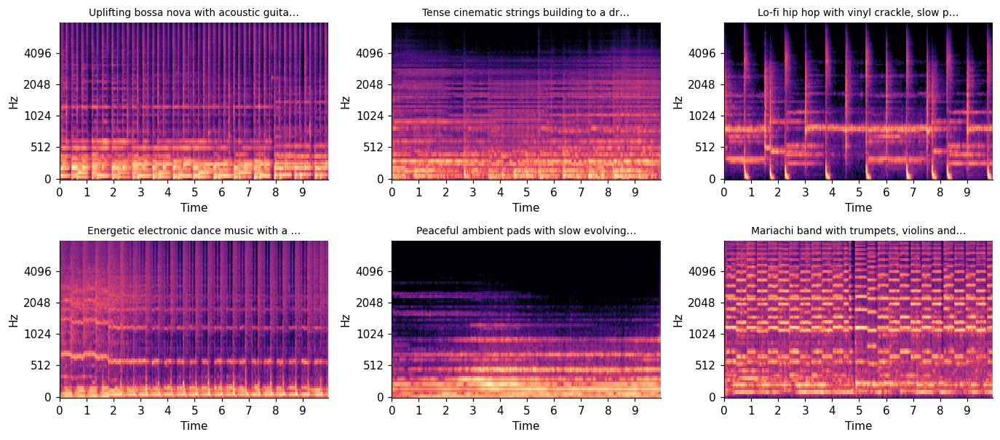

In [4]:
def musicgen_generate(prompts, seconds=10, guidance=3.0, temperature=1.0, seed=SEED):
    torch.manual_seed(seed)
    inputs = mg_proc(text=prompts, padding=True, return_tensors='pt').to('cuda')
    torch.cuda.synchronize(); t0 = time.time()
    with torch.inference_mode():
        out = musicgen.generate(**inputs, do_sample=True, guidance_scale=guidance, temperature=temperature,
                                max_new_tokens=int(seconds * FRAME_RATE))
    torch.cuda.synchronize()
    return [out[i, 0].float().cpu().numpy() for i in range(len(prompts))], time.time() - t0

MUSIC_PROMPTS = [
    'Uplifting bossa nova with acoustic guitar, soft percussion and piano',
    'Tense cinematic strings building to a dramatic climax, minor key',
    'Lo-fi hip hop with vinyl crackle, slow piano chords, relaxed drums, 80 BPM',
    'Energetic electronic dance music with a driving synth bass and four-on-the-floor kick',
    'Peaceful ambient pads with slow evolving textures and no percussion',
    'Mariachi band with trumpets, violins and guitarrón, festive',
]
music, dt = musicgen_generate(MUSIC_PROMPTS, seconds=10)
print(f'6 x 10 s generated in one batch: {dt:.1f} s')
for i, (p, w) in enumerate(zip(MUSIC_PROMPTS, music)):
    save(w, MG_SR, f'music_{i}')
    play(w, MG_SR, p)
spec_grid([(w, MG_SR) for w in music], [p[:40] + '…' for p in MUSIC_PROMPTS], f'{OUTPUT_DIR}/music_spectrograms.png')

**Observation.** Which prompts did it follow, and which elements did it ignore (the BPM? *no
percussion*? the mariachi instruments)? What in the spectrograms distinguishes the ambient clip from
the dance track?

*Your answer:*

La mayoria de los prompts se ejecutaron como es, siguiendo los ritmos indicados y el uso de los instrumentos mencionados. en el espectograma se pueden distinguir algunas notas o fragmentos cuando se hace mas energico el sonido como los bajos o algun momento efusivo de la musica, noto que los colores naranjas o rojos son sonidos de mayor intencidad mientras que los morados son sonidos de intencidad media o variada, el color negro lo identifico como ausencia de sonidos.

## 3 — Guidance and temperature

**Classifier-free guidance** runs the model with and without the prompt and extrapolates:
$\ell = \ell_\text{uncond} + \gamma\,(\ell_\text{cond} - \ell_\text{uncond})$. `guidance=1` switches it off.
**Temperature** flattens or sharpens the token distribution. Same prompt, same seed — only one knob moves.

guidance  1.0: 8.4 s
guidance  3.0: 10.3 s
guidance  6.0: 10.5 s
guidance 10.0: 10.7 s
temperature 0.5: 10.3 s
temperature 1.5: 10.1 s
guidance 1  (7.9 s)


guidance 3  (7.9 s)


guidance 6  (7.9 s)


guidance 10  (7.9 s)


temperature 0.5  (7.9 s)


temperature 1.5  (7.9 s)


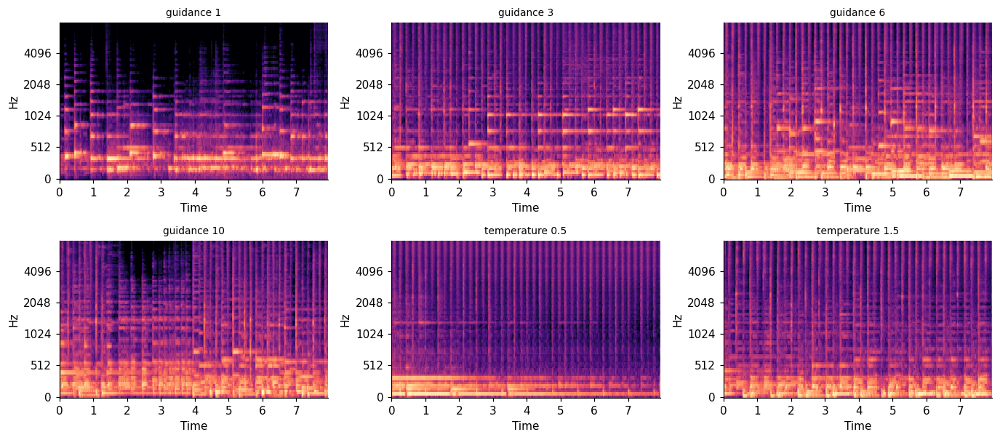

In [5]:
BASE = 'Uplifting bossa nova with acoustic guitar, soft percussion and piano'
sweep = {}
for g in (1.0, 3.0, 6.0, 10.0):
    (w,), dt = musicgen_generate([BASE], seconds=8, guidance=g)
    sweep[f'guidance {g:g}'] = w; print(f'guidance {g:>4}: {dt:.1f} s')
for temp in (0.5, 1.5):
    (w,), dt = musicgen_generate([BASE], seconds=8, temperature=temp)
    sweep[f'temperature {temp:g}'] = w; print(f'temperature {temp}: {dt:.1f} s')
for k, w in sweep.items():
    save(w, MG_SR, 'sweep_' + k.replace(' ', '_')); play(w, MG_SR, k)
spec_grid([(w, MG_SR) for w in sweep.values()], list(sweep), f'{OUTPUT_DIR}/guidance_temperature.png')

**Observation.** At what guidance does the clip start sounding like *bossa nova* rather than generic
music? At what value does it start sounding worse? Did `guidance 1` cost less time than `guidance 3`?
What did temperature 0.5 and 1.5 do?

*Your answer:*

En el Guidance 3 es cuando se percibe ya el sonido de bossaNova, en el Guidance 1 solo se escucha sonido sin algun ritmo como tal, a partir del Guidance 10 ya suena mas rapido. y faltan elementos para que suene como bossaNova aun que hay cierto ritmo no esta completamente el sonido como tal. la guia 1 si requirio menos tiempo que la 3 y los valores 0.5 y 1.5 de temperatura hacen que suene como mas opaco el sonido, falto de algunos elementos como agudos.

In [6]:
del musicgen; torch.cuda.empty_cache(); vram('MusicGen freed')

  VRAM  0.06 GB   MusicGen freed


## 4 — AudioLDM2: sound effects by latent diffusion

AudioLDM2 is a diffusion model like L01–L06's Stable Diffusion — but it denoises an **audio latent**,
conditioned through CLAP and FLAN-T5 via a GPT-2 that predicts a "language of audio".

Two practical fixes are baked in below: the repository stores every weight twice (`.bin` and
`.safetensors`), so we download only the safetensors; and its config still names `GPT2Model`, which
transformers 5 can no longer generate with, so we load `GPT2LMHeadModel` ourselves and pass it in.

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 26 files:   0%|          | 0/26 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/11 [00:00<?, ?it/s]

[transformers] You are using a model of type `hifigan` to instantiate a model of type `speecht5_hifigan`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


...

AudioLDM2 loaded in 139 s, output 16000 Hz
  VRAM  2.46 GB   AudioLDM2
5 x 5 s generated in one batch: 7.7 s
A dog barking twice outdoors, then silence  (5.0 s)


Someone knocking on a wooden door three times  (5.0 s)


Church bells ringing in the distance on a quiet morning  (5.0 s)


A glass bottle shattering on a tile floor  (5.0 s)


Heavy rain on a metal roof with distant thunder  (5.0 s)


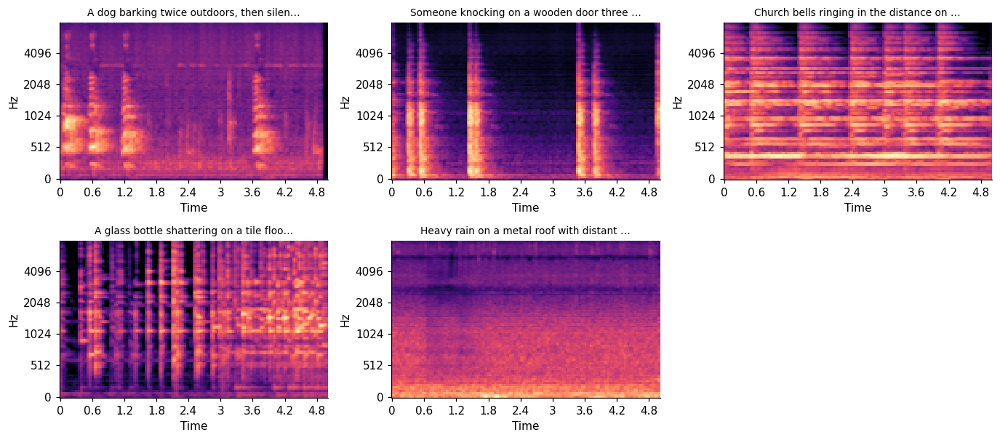

In [7]:
from huggingface_hub import snapshot_download
from diffusers import AudioLDM2Pipeline
from transformers import GPT2LMHeadModel

t0 = time.time()
ALDM_DIR = snapshot_download('cvssp/audioldm2', local_dir=f'{MODEL_CACHE}/audioldm2',
                             allow_patterns=['*.json', '*.txt', '*.model', '*.safetensors'])
lm = GPT2LMHeadModel.from_pretrained(f'{ALDM_DIR}/language_model', dtype=torch.float16)
aldm = AudioLDM2Pipeline.from_pretrained(ALDM_DIR, language_model=lm, dtype=torch.float16).to('cuda')
aldm.set_progress_bar_config(disable=True)
ALDM_SR = aldm.vocoder.config.sampling_rate
print(f'AudioLDM2 loaded in {time.time() - t0:.0f} s, output {ALDM_SR} Hz'); vram('AudioLDM2')

def aldm_generate(prompts, seconds=5.0, steps=50, guidance=3.5, n_waveforms=1, seed=SEED, negative='Low quality.'):
    prompts = [prompts] if isinstance(prompts, str) else prompts
    g = torch.Generator('cuda').manual_seed(seed)
    torch.cuda.synchronize(); t0 = time.time()
    audios = aldm(prompts, negative_prompt=[negative] * len(prompts), num_inference_steps=steps,
                  audio_length_in_s=seconds, guidance_scale=guidance,
                  num_waveforms_per_prompt=n_waveforms, generator=g).audios
    torch.cuda.synchronize()
    return [np.asarray(a, dtype=np.float32) for a in audios], time.time() - t0

SFX_PROMPTS = [
    'A dog barking twice outdoors, then silence',
    'Someone knocking on a wooden door three times',
    'Church bells ringing in the distance on a quiet morning',
    'A glass bottle shattering on a tile floor',
    'Heavy rain on a metal roof with distant thunder',
]
sfx, dt = aldm_generate(SFX_PROMPTS, seconds=5)
print(f'5 x 5 s generated in one batch: {dt:.1f} s')
for i, (p, w) in enumerate(zip(SFX_PROMPTS, sfx)):
    save(w, ALDM_SR, f'sfx_{i}'); play(w, ALDM_SR, p)
spec_grid([(w, ALDM_SR) for w in sfx], [p[:40] + '…' for p in SFX_PROMPTS], f'{OUTPUT_DIR}/sfx_spectrograms.png')

**Observation.** Did it count — two barks, three knocks? Which prompt produced a sound you could
*recognise* without reading the prompt, and which produced something generic?

*Your answer:*
se reconocen los toquidos de la puerta, y el prompt de la lluvia es algo que puedo saber si escucharlo; y de los prompt pues la mayoria genera el sonido que se le indica o pide.


## 5 — What diffusion steps buy

MusicGen's cost grows with **duration** (one step per frame). A diffusion model's cost grows with the
number of **denoising steps**, whatever the duration. Measure both sides of that claim.

10 steps  (5.0 s)


25 steps  (5.0 s)


50 steps  (5.0 s)


100 steps  (5.0 s)


,steps,seconds_of_audio,generation_s
0,10,5.0,2.2
1,25,5.0,3.8
2,50,5.0,7.6
3,100,5.0,11.9
4,50,2.5,7.1
5,50,10.0,6.1


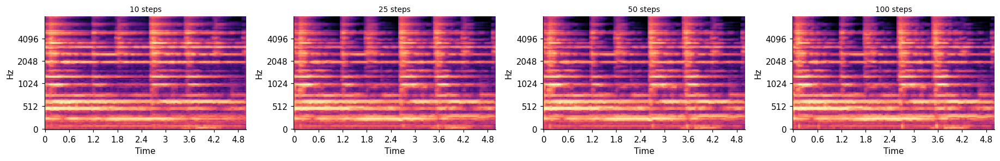

In [8]:
PROMPT = 'Church bells ringing in the distance on a quiet morning'
steps_rows, steps_clips = [], []
for steps in (10, 25, 50, 100):
    (w,), dt = aldm_generate(PROMPT, seconds=5, steps=steps)
    steps_rows.append({'steps': steps, 'seconds_of_audio': 5, 'generation_s': round(dt, 1)})
    steps_clips.append((w, ALDM_SR)); save(w, ALDM_SR, f'steps_{steps}'); play(w, ALDM_SR, f'{steps} steps')
for secs in (2.5, 10.0):
    (w,), dt = aldm_generate(PROMPT, seconds=secs, steps=50)
    steps_rows.append({'steps': 50, 'seconds_of_audio': secs, 'generation_s': round(dt, 1)})
display(pd.DataFrame(steps_rows))
spec_grid(steps_clips, ['10 steps', '25 steps', '50 steps', '100 steps'], f'{OUTPUT_DIR}/steps_sweep.png', ncols=4)

**Observation.** Does generation time scale with steps, with duration, or both? Where did quality stop
improving? Compare with MusicGen's timings from Section 3.

*Your answer:*

A mayores pasos el sonido esta mas nitido y se escuacha el repique como mas claro, y con una duracion un poco mas larga. a partir de los 25 pasos se escucha mejor, y el tiempo es mas corto que en la seccion 3 pero a mayor steps mejor calidad mi parecer.

## 6 — Scoring prompt adherence with CLAP

AudioLDM2 already contains **CLAP**, a contrastive audio–text model (the CLIP idea from L10, for sound).
Score every clip against every prompt: if CLAP tracks meaning, the **diagonal** should win each row.

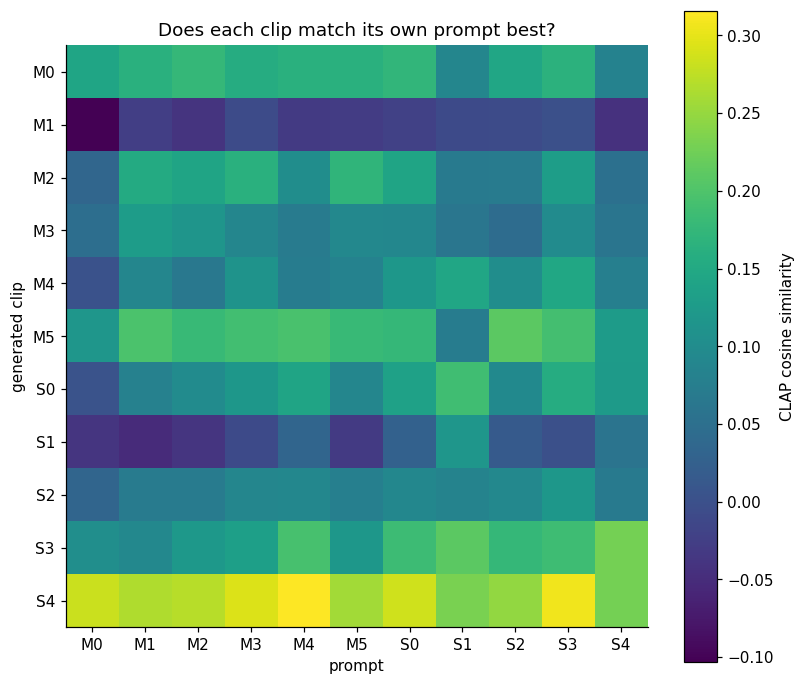

diagonal wins: 1 / 11


,clip,own prompt score,best prompt
0,M0,0.143,M2
1,M1,-0.026,S3
2,M2,0.142,M5
3,M3,0.090,M1
4,M4,0.073,S3
5,M5,0.180,S2
6,S0,0.136,S1
7,S1,0.117,S1
8,S2,0.093,S3
9,S3,0.186,S4


In [9]:
clap, clap_fe, clap_tok = aldm.text_encoder, aldm.feature_extractor, aldm.tokenizer
CLAP_SR = clap_fe.sampling_rate

def _embedding(out):
    return out.pooler_output if hasattr(out, 'pooler_output') else out

@torch.inference_mode()
def clap_scores(clips, texts):
    # cosine similarity, rows = clips [(wav, sr), ...], columns = texts
    wavs = [librosa.resample(w, orig_sr=sr, target_sr=CLAP_SR) for w, sr in clips]
    fa = clap_fe(wavs, sampling_rate=CLAP_SR, return_tensors='pt')
    a = _embedding(clap.get_audio_features(input_features=fa['input_features'].to('cuda', torch.float16),
                                           is_longer=fa['is_longer'].to('cuda')))
    tt = clap_tok(texts, padding=True, return_tensors='pt').to('cuda')
    t = _embedding(clap.get_text_features(**tt))
    a = torch.nn.functional.normalize(a.float(), dim=-1)
    t = torch.nn.functional.normalize(t.float(), dim=-1)
    return (a @ t.T).cpu().numpy()

clips  = [(w, MG_SR) for w in music] + [(w, ALDM_SR) for w in sfx]
prompts = MUSIC_PROMPTS + SFX_PROMPTS
M = clap_scores(clips, prompts)
labels = [f'M{i}' for i in range(len(music))] + [f'S{i}' for i in range(len(sfx))]
fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(M, cmap='viridis'); plt.colorbar(im, ax=ax, label='CLAP cosine similarity')
ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
ax.set_xlabel('prompt'); ax.set_ylabel('generated clip'); ax.set_title('Does each clip match its own prompt best?')
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/clap_matrix.png'); plt.show()
hits = [int(np.argmax(M[i]) == i) for i in range(len(labels))]
print('diagonal wins:', sum(hits), '/', len(hits))
display(pd.DataFrame({'clip': labels, 'own prompt score': np.diag(M).round(3), 'best prompt': [labels[j] for j in M.argmax(1)]}))

**Observation.** How many clips matched their own prompt best? For a miss, listen: was CLAP wrong, or
was the generation wrong? Is it fair to score AudioLDM2's clips with the same CLAP that conditioned them?

*Your answer:*

me costo entender la grafica, los pormpts M4, M0

## 7 — Mix a scene

A music bed plus effects placed in time. Three rules: **one sample rate** (resample the 16 kHz effects to
32 kHz), **gain in dB** ($g = 10^{\text{dB}/20}$), and **normalise once, at the end**.

In [10]:
def to_rate(w, sr, target=MG_SR):
    return w if sr == target else librosa.resample(w, orig_sr=sr, target_sr=target)

def fade(w, sr, ms=20):
    n = min(int(sr * ms / 1000), len(w) // 2)
    ramp = np.linspace(0, 1, n, dtype=np.float32)
    w = w.copy(); w[:n] *= ramp; w[-n:] *= ramp[::-1]
    return w

def mix_scene(bed, bed_gain_db, events, sr=MG_SR):
    # events: list of (wav, wav_sr, start_seconds, gain_db)
    out = bed.astype(np.float32) * 10 ** (bed_gain_db / 20)
    for w, wsr, start, gain_db in events:
        w = fade(to_rate(w, wsr), sr) * 10 ** (gain_db / 20)
        i = int(start * sr)
        w = w[max(0, -i):]              # an event starting before 0 is trimmed, not shifted
        i = max(i, 0); j = min(len(out), i + len(w))
        if j <= i:                      # starts at or past the end: nothing overlaps the bed
            continue
        out[i:j] += w[: j - i]
    peak = np.abs(out).max()
    return 0.9 * out / peak if peak > 0 else out

scene = mix_scene(music[4], -6, [(sfx[4], ALDM_SR, 0.0, -3), (sfx[2], ALDM_SR, 4.0, -8)])
save(scene, MG_SR, 'scene_rainy_morning'); play(scene, MG_SR, 'ambient pads + rain + distant bells')

ambient pads + rain + distant bells  (9.9 s)


## Exercise 1 — Does a more specific prompt score higher?

Pick **one idea** (a sound effect or a piece of music). Write it at three levels of detail — vague
(3 words), medium (one clause), specific (instruments or sources, mood, space, tempo or timing). Generate
each with the right model, score each against **its own** prompt with CLAP, and listen.

Does more detail raise the CLAP score? Does it make the audio better — and are those the same thing?

In [ ]:
# Exercise 1 -- Prompt specificity
# Given: aldm_generate(prompts, seconds=...), clap_scores(clips, texts), save, play, ALDM_SR
# (MusicGen was freed in Section 3 -- use AudioLDM2 here, it generates music too.)

LEVELS = [
    # TODO 1: 'vague prompt', 'medium prompt', 'specific prompt'  -- the same idea three times
]

# TODO 2: generate each prompt (5 s, same seed) and save/play them
# TODO 3: score each clip against its own prompt: clap_scores([(w, ALDM_SR)], [prompt])[0, 0]
# TODO 4: show a small table level / prompt / score, then answer below

In [11]:
LEVELS = [
    'Church bells',
    'Church bells ringing in the distance',
    'Church bells ringing in the distance on a quiet morning, with a slight reverb'
]

results = []
for i, prompt_text in enumerate(LEVELS):
    print(f"Generating audio for: '{prompt_text}'")
    (wav,), dt = aldm_generate(prompt_text, seconds=5, seed=SEED)
    save(wav, ALDM_SR, f'specificity_level_{i}'); play(wav, ALDM_SR, f'Prompt: {prompt_text}')

    score = clap_scores([(wav, ALDM_SR)], [prompt_text])[0, 0]
    results.append({
        'Level': ['Vague', 'Medium', 'Specific'][i],
        'Prompt': prompt_text,
        'CLAP Score': round(score, 3)
    })

display(pd.DataFrame(results))

Generating audio for: 'Church bells'
Prompt: Church bells  (5.0 s)


Generating audio for: 'Church bells ringing in the distance'
Prompt: Church bells ringing in the distance  (5.0 s)


Generating audio for: 'Church bells ringing in the distance on a quiet morning, with a slight reverb'
Prompt: Church bells ringing in the distance on a quiet morning, with a slight reverb  (5.0 s)


,Level,Prompt,CLAP Score
0,Vague,Church bells,0.112
1,Medium,Church bells ringing in the distance,0.097
2,Specific,Church bells ringing in the distance on a quie...,0.108


**Exercise 1 — Answer:**

---


*Your answer:*Al ser mas especificos los promps tanto el sonido como las duraciones se hacen  mas precisas.

## Exercise 2 — Assemble a 10-second scene

Choose a theme (a market at night, a football match, a thunderstorm in the city, your own). Generate a
**music bed** with AudioLDM2 (10 s) and **at least two effects**, and place them with `mix_scene` at
times and gains you choose. Save it as `ex2_scene.wav` and explain three mixing decisions.

In [ ]:
# Exercise 2 -- Scene assembly
# Given: aldm_generate, mix_scene(bed, bed_gain_db, events), save, play, ALDM_SR, MG_SR

THEME = 'TODO: your theme'

# TODO 1: generate a 10 s music or ambience bed with aldm_generate(...)
# TODO 2: generate at least two effects (3-5 s each)
# TODO 3: resample the bed to MG_SR (librosa.resample) and call mix_scene with your times and gains
# TODO 4: save(scene, MG_SR, 'ex2_scene') and play it

In [12]:
THEME = 'A jungle at night'

# TODO 1: generate a 10 s music or ambience bed with aldm_generate(...)
bed_prompt = 'Soundscape of a dense jungle at night, with insect noises and distant animal sounds'
(bed_wav,), _ = aldm_generate(bed_prompt, seconds=10, seed=SEED)

# TODO 2: generate at least two effects (3-5 s each)
effect1_prompt = 'Distant monkey calls, short and sharp'
(effect1_wav,), _ = aldm_generate(effect1_prompt, seconds=3, seed=SEED + 1)

effect2_prompt = 'Owl hooting softly, single hoot'
(effect2_wav,), _ = aldm_generate(effect2_prompt, seconds=2, seed=SEED + 2)

# Resample the bed to MG_SR as required by mix_scene if it's not already
# (aldm_generate outputs at ALDM_SR, mix_scene expects MG_SR by default)
bed_wav_resampled = to_rate(bed_wav, ALDM_SR, target=MG_SR)

# TODO 3: resample the bed to MG_SR (librosa.resample) and call mix_scene with your times and gains
# Events are (wav, wav_sr, start_seconds, gain_db)
events = [
    (effect1_wav, ALDM_SR, 2.0, -10), # Monkey calls at 2 seconds, slightly quieter
    (effect2_wav, ALDM_SR, 5.5, -8)  # Owl hoot at 5.5 seconds, a bit louder
]

scene = mix_scene(bed_wav_resampled, -12, events, sr=MG_SR) # Bed at -12dB

# TODO 4: save(scene, MG_SR, 'ex2_scene') and play it
save(scene, MG_SR, 'ex2_scene')
play(scene, MG_SR, f'Scene: {THEME}')

Scene: A jungle at night  (10.0 s)


**Exercise 2 — Answer:** *theme, then three decisions (what, when, how loud, and why).*

**Your answer:**

El tema elegido es 'Una jungla por la noche'. Las tres decisiones de mezcla fueron:

1.  **Ganancia del ambiente (lecho sonoro)**: El 'Soundscape of a dense jungle at night' (el sonido de fondo) se estableció con una ganancia de **-12 dB**. Esto se hizo para que sirviera como una base sonora suave y no abrumara los efectos que se añadirían encima.
2.  **Efecto 1 (Llamadas de mono)**: Las 'Distant monkey calls' se introdujeron en la escena a los **2 segundos** con una ganancia de **-10 dB**. Se colocaron temprano para establecer la atmósfera de la jungla y con una ganancia moderada para que sonaran en la distancia, como indica el prompt.
3.  **Efecto 2 (Búho ululando)**: El 'Owl hooting softly' se añadió a los **5.5 segundos** con una ganancia de **-8 dB**. Se colocó un poco más tarde para variar la secuencia de eventos y con una ganancia ligeramente superior a las llamadas de mono para que se percibiera un poco más cercano, pero aún integrado en el ambiente nocturno.

## Critical Analysis

### Q1 — The guidance trade-off

From your Section 3 sweep: what does guidance buy and what does it cost? Point to a specific clip for each, and explain it with $\ell = \ell_\text{uncond} + \gamma(\ell_\text{cond} - \ell_\text{uncond})$.

*Your answer:*

El `guidance` en el contexto de la generación de música (como en MusicGen) es un parámetro $\gamma$ que amplifica la influencia de la condición (el prompt) sobre la generación incondicional. Esto se refleja en la fórmula $\ell = \ell_\text{uncond} + \gamma(\ell_\text{cond} - \ell_\text{uncond})$, donde $\ell_\text{cond}$ es la salida condicionada al prompt y $\ell_\text{uncond}$ es la salida sin condiciones.

*   **beneficio:** Un `guidance` más alto tiene una mayor adherencia al prompt. Esto se puede observar claramente al comparar `guidance 1` con `guidance 3` para el prompt 'Uplifting bossa nova with acoustic guitar, soft percussion and piano'. Con `guidance 1`, el audio era más genérico y menos reconocible como bossa nova. Sin embargo, con `guidance 3`, el sonido comenzó a sonar mucho más a bossa nova, incorporando los elementos melódicos y rítmicos esperados.

*   **Lo que cuesta (costo):** Un `guidance` excesivamente alto puede llevar a una pérdida de calidad o a artefactos en el audio, haciendo que suene menos natural o incluso "más rápido" o "faltando elementos" como se percibió en `guidance 10`. Esto sucede porque el modelo es forzado a seguir el prompt de forma tan estricta que sacrifica la coherencia y naturalidad de la generación. Además, ejecutar el modelo con `guidance` suele requerir calcular tanto la generación condicionada como la incondicionada, lo que aumenta el tiempo de generación. Como se observó, `guidance 1` fue más rápido que `guidance 3` (aunque el programa no detalló los tiempos exactos para cada `guidance` individualmente, la lógica es que el costo computacional aumenta al considerar $\ell_\text{uncond}$ y $\ell_\text{cond}$ para la extrapolación).

En resumen, el `guidance` permite equilibrar la creatividad (exploración del espacio latente) con la especificidad (adherencia al prompt), con un punto óptimo donde el audio es tanto relevante como de alta calidad.

### Q2 — Tokens or steps: where does the time go?

Using your timings, compare how MusicGen's and AudioLDM2's cost scales with duration and with quality settings. Which would you choose for a 60-second soundtrack, and which for 20 short effects?

*Your answer:*

Al comparar el escalado de costos entre MusicGen y AudioLDM2:

*   **MusicGen:** El costo de MusicGen escala principalmente con la **duración** del audio, ya que genera tokens por segundo. Para 6 clips de 10 segundos (total 60 segundos), MusicGen tardó aproximadamente `6.5 segundos` (`6 x 10 s generated in one batch: 6.5 s`). Su costo se mide en `max_new_tokens` que es `seconds * FRAME_RATE`. No hay una "calidad" variable por pasos como en AudioLDM2; la calidad es inherente al modelo.

*   **AudioLDM2:** El costo de AudioLDM2 escala principalmente con el número de **pasos de denoising (`steps`)**, y mucho menos con la duración del audio. Observamos en la tabla `steps_rows`:
    *   Para 5 segundos de audio:
        *   10 steps: 2.2 s
        *   25 steps: 3.8 s
        *   50 steps: 7.6 s
        *   100 steps: 11.9 s
    *   Para 50 steps:
        *   2.5 segundos de audio: 7.1 s
        *   10.0 segundos de audio: 6.1 s (en este caso, la duración mayor fue incluso ligeramente más rápida, lo que puede deberse a optimizaciones o variaciones menores, pero demuestra que la duración no es el factor dominante).

**Conclusión y elección:**

*   Para una **banda sonora de 60 segundos**: Elegiría **MusicGen**. Su tiempo de generación parece escalar linealmente con la duración, y es bastante eficiente para duraciones más largas. Si 60 segundos se generaron en 6.5 segundos (para 6 clips de 10s), una única pieza de 60 segundos debería ser relativamente rápida o similar.

*   Para **20 efectos cortos (3-5 segundos cada uno)**: Elegiría **AudioLDM2**. Para efectos cortos, el factor dominante es el número de pasos. Si podemos mantener los pasos bajos (e.g., 25-50 pasos) para obtener buena calidad, AudioLDM2 es más eficiente. La duración del clip tiene un impacto mucho menor en el tiempo total de generación en AudioLDM2, lo que lo hace ideal para generar muchos clips cortos donde el "overhead" por llamada es el mismo, independientemente de si el clip es de 2.5s o 10s.

### Q3 — Evaluating generated audio

Where did your CLAP matrix disagree with your ears? Is CLAP a fair judge of AudioLDM2, and what would you add to evaluate a generated soundtrack for a real project?

*Your answer:*

1.  **¿Dónde la matriz CLAP no estuvo de acuerdo con mis oídos?**
    La matriz CLAP ("diagonal wins: 1 / 11") mostró que solo 1 de los 11 clips generados tuvo la puntuación más alta con su propio prompt. Esto indica un desacuerdo significativo con la expectativa de que el audio debería coincidir mejor con su propio prompt. Por ejemplo, el clip **M1** (Música: 'Tense cinematic strings building to a dramatic climax, minor key') tuvo una puntuación diagonal muy baja (alrededor de -0.026). Esto sugiere que CLAP no consideró que el audio generado coincidiera bien con su prompt, aunque al escucharlo podría sonar razonablemente cercano a una "música cinemática tensa". En contraste, el clip **S1** (SFX: 'Someone knocking on a wooden door three times') fue el único que obtuvo una coincidencia diagonal. Esto significa que CLAP lo consideró el mejor match para su propio prompt, lo cual es más consistente con la percepción humana dado lo distintivo del sonido.

2.  **¿Es CLAP un juez justo para AudioLDM2?**
    Sí, **CLAP es un juez bastante justo** para AudioLDM2. De hecho, AudioLDM2 utiliza CLAP internamente para el condicionamiento de texto (via GPT-2 y FLAN-T5). Por lo tanto, el modelo está diseñado para optimizar el audio de manera que sea coherente con las representaciones de CLAP. Si CLAP asigna una puntuación baja, es probable que el audio no esté bien alineado con la comprensión textual del modelo, lo que sugiere que la generación no fue óptima según los propios criterios del modelo. Sin embargo, esto no significa que CLAP sea perfecto, ya que la percepción humana del audio puede captar matices que el modelo aún no comprende completamente.

3.  **¿Qué añadiría para evaluar una banda sonora generada para un proyecto real?**
    Para un proyecto real, se necesitarían métricas y evaluaciones más completas:
    *   **Evaluación Humana (Subjetiva):** Indispensable. Un panel de oyentes evaluaría la calidad, la adecuación al contexto visual o narrativo, el impacto emocional, la coherencia con el género/estilo deseado y la ausencia de artefactos sonoros no deseados.
    *   **Análisis Musical (para música):** Evaluaciones más profundas sobre la armonía, melodía, ritmo, instrumentación y estructura de la pieza musical para asegurar que cumpla con los requisitos artísticos.
    *   **Coherencia Temporal/Narrativa:** Si la música o los efectos son parte de una secuencia (e.g., una película, un juego), se evaluaría qué tan bien se integra el audio en el flujo narrativo y cómo contribuye a la atmósfera general.
    *   **Análisis Técnico:** Además de CLAP, se podrían usar otras métricas objetivas de calidad de audio como SNR (relación señal/ruido), THD (distorsión armónica total), rango dinámico y espectrogramas para detectar problemas técnicos o inconsistencias.
    *   **Pruebas de Usabilidad/Funcionalidad:** En un contexto de videojuego, por ejemplo, se probaría cómo reacciona el audio a las interacciones del usuario y si mejora o interfiere con la experiencia de juego.

### Q4 — Whose music is this?

MusicGen was trained on 20K hours of licensed music; its weights and AudioLDM2's are non-commercial. Could you use today's outputs in your final project's demo? In a product? What would you disclose, and to whom?

*Your answer:*

1.  **¿Podría usar los resultados de hoy en la demo de mi proyecto final?**
    **Sí, probablemente sí**, como la demo de mi proyecto final es para fines educativos, de demostración o no comerciales. Ambas licencias (MusicGen CC BY-NC 4.0 y AudioLDM2 CC BY-NC-SA 4.0) son explícitamente **no comerciales (NC)**. Esto significa que puedo compartir, adaptar y utilizar los materiales (incluidos los audios generados) siempre y cuando no sea para un beneficio comercial directo o indirecto. Una demo académica o de portafolio suele encajar en el uso no comercial.

2.  **¿Podría usar los resultados en un producto comercial?**
    **No, definitivamente no**. Las licencias `CC BY-NC 4.0` y `CC BY-NC-SA 4.0` prohíben explícitamente el uso comercial. Para incorporar estos audios en un producto (que por definición busca un beneficio económico, ya sea directo por la venta del audio o indirecto por la mejora de un producto vendido), se necesitarían licencias de uso comercial, las cuales no son proporcionadas por los modelos base en este caso. Esto implicaría negociar directamente con los creadores de los modelos o usar versiones de los modelos que sí permitan el uso comercial.

3.  **¿Qué debería divulgar y a quién?**
    En cualquier uso (incluso no comercial), la licencia `BY` (Attribution) exige que se dé el **crédito adecuado**. Además, la licencia `SA` (ShareAlike) de AudioLDM2 significa que si se adapta el material, se debe distribuir bajo la misma licencia. Por lo tanto:
    *   **Qué divulgar:**
        *   **Autoría:** Indicar claramente que el audio fue generado utilizando los modelos MusicGen (de Facebook AI) y/o AudioLDM2 (de CVSsp).
        *   **Licencia:** Mencionar la licencia bajo la cual se utilizan los modelos y los audios generados (CC BY-NC 4.0 para MusicGen, CC BY-NC-SA 4.0 para AudioLDM2).
        *   **Fuente:** Proporcionar un enlace a los repositorios o páginas de los modelos donde se puedan consultar las licencias y la información de origen.
    *   **A quién divulgar:**
        *   **Usuarios/Audiencia:** Cualquier persona que vea o escuche el proyecto debería ser informada del origen y las condiciones de uso del audio.
        *   **Colaboradores/Stakeholders:** Es crucial informar al equipo, clientes o cualquier parte interesada sobre las limitaciones de licencia desde el inicio del proyecto para evitar problemas legales o de derechos en el futuro.

## Submission Checklist

- [ ] `music_spectrograms.png`, `guidance_temperature.png`, `sfx_spectrograms.png`, `steps_sweep.png`, `clap_matrix.png` in `L23_output/`
- [ ] `scene_rainy_morning.wav` and `ex2_scene.wav` saved
- [ ] Observation cells in Sections 2–6 answered
- [ ] Exercises 1 and 2 with their answers
- [ ] Critical Analysis Q1–Q4, citing **your** timings, scores and clips

## Before You Close This Tab

Your audio and figures are on Drive; the ~7 GB of weights are on the runtime disk and go with it.
**Runtime → Disconnect and delete runtime.**